# Comparison with RNAalidfold - dataset 1 - manually curated alignments

In [16]:
import pandas as pd
import os
import numpy as np
import subprocess

from Bio import SearchIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from Bio import SeqIO, AlignIO
from Bio import Align
from collections import defaultdict
import pyranges as pr

import re
import RNA

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_auc_score, top_k_accuracy_score, roc_curve, precision_recall_curve, average_precision_score
from pathlib import Path
import matplotlib.patches as mpatches

In [8]:
data_path = 'data'

# Functions

In [4]:
def bpseq2mat(bpseq):

    
    ci_matrix = np.zeros((max(bpseq[0]),max(bpseq[0])))
    ci_matrix[bpseq[0][bpseq[1]>0]-1,
              bpseq[1][bpseq[1]>0]-1] = 1
    return ci_matrix
    
def get_comparna_gt(pdb_id):

    gt_comparna_folder = data_path
    
    path_wccis = os.path.join(gt_comparna_folder, "comparna_pdb_WCcis", pdb_id+".bpseq" )
    path_ext = os.path.join(gt_comparna_folder,"comparna_pdb_ext", pdb_id+"_ext.bpseq")
    seq, bpseq = open_bpseq(path_wccis)
    WCmatrix = bpseq2mat(bpseq)
    seq, bpseq = open_bpseq(path_ext)
    truematrix = bpseq2mat(bpseq)
    allmatrix = WCmatrix - (truematrix - WCmatrix)
    extmatrix = truematrix - WCmatrix

    return allmatrix, WCmatrix, extmatrix


def open_bpseq(bpseq_file):
    
    seq = ""
    bpseq_idx = []
    bpseq_ct = []
    lastidx = "0"
    with open(bpseq_file) as f:
        for line in f:
            splitted = line.rstrip().split(" ")
            if splitted[0]!=lastidx:
                seq += splitted[1]
                lastidx = splitted[0]
            bpseq_idx.append(splitted[0])
            bpseq_ct.append(splitted[2])
    bpseq = [np.array(bpseq_idx, dtype=int),np.array(bpseq_ct, dtype=int)]
    return seq, bpseq


def get_predicted_matrix(pred_matrix, noncontact_mask, x_get, y_get):

    contact_values = pred_matrix[x_get, y_get]
    noncontact_values = pred_matrix[noncontact_mask]

    pred_values = np.concatenate((noncontact_values, contact_values), axis=0)
    return pred_values


def parse_alifold_output(file_aliout):

    all_rows = []
    with open(file_aliout,"r") as f:
    
        # Last row contains dot bracket notation
        lines = f.readlines()[2:]
    
        dbnotation = lines[-1].strip()
        len_seq = len(dbnotation)
        
        for line in lines[:-1]:
            items = line.split()
            i, j, _, p_ij = items[:4]
            all_rows.append((int(i)-1, int(j)-1, float(p_ij[:-1])))
    
    df = pd.DataFrame(all_rows, columns=['pos_i', 'pos_j', 'p_ij'])

    # Extract row and column information
    rowIDs = df['pos_i']
    colIDs = df['pos_j']
    
    mat = np.zeros((len_seq, len_seq))
    mat[rowIDs,colIDs] = df['p_ij']

    return mat, dbnotation


def get_informative_indices_rnaalifold(aligned_seq, sep="-", dms_filter=False):
    
    # Get indices where there is a base
    if dms_filter:
        seq_indices = [i for i, elem in enumerate(aligned_seq) if elem != sep and elem in ["A","C"]]
    else:
        seq_indices = [i for i, elem in enumerate(aligned_seq) if elem != sep]
    return seq_indices

    
def clean_aligned_seq(aligned_seq, sep="-", dbnot=None, dms_filter=False):
    
    # Get indices where there is a base
    seq_indices = get_informative_indices_rnaalifold(aligned_seq, sep=sep, dms_filter=dms_filter)

    clean_dbnot = None
    clean_seq = ''.join([aligned_seq[i] for i in seq_indices])
    if dbnot:
        clean_dbnot = ''.join([dbnot[i] for i in seq_indices])
        
    return clean_seq, clean_dbnot


def reduce(matrix, idx_to_del):

    matrix = np.delete(matrix, idx_to_del, axis=0)
    matrix = np.delete(matrix, idx_to_del, axis=1)

    return matrix

In [5]:
    
def get_rnaalifold_reduced_matrix_case1_fasta(file_final_aliout, fasta_alignment, orig_seq, reference_seq=None):

    mat1, dbnotation = parse_alifold_output(file_final_aliout)  
    # Subset matrix to positions with sequence
    pdb_entry = list(AlignIO.parse(fasta_alignment, "fasta"))[0]

    mat2, clean_seq = None, None
    for entry in pdb_entry:
        
        aligned_seq = entry.seq
        clean_seq, _ = clean_aligned_seq(str(aligned_seq))
        clean_seq = clean_seq.upper()

        if orig_seq in clean_seq and len(orig_seq) < len(clean_seq):
            assert len(aligned_seq) == mat1.shape[0]
            target_idxs = get_informative_indices_rnaalifold(aligned_seq, sep="-", dms_filter=False)
            remove_idxs = list(set(list(range(len(aligned_seq)))).difference(set(target_idxs)))
            mat2 = reduce(mat1, remove_idxs)
            mat2 = mat2 + mat2.T
            break
    return mat2, clean_seq


def get_rnaalifold_reduced_matrix(file_final_aliout, fasta_alignment, orig_seq):

    mat1, dbnotation = parse_alifold_output(file_final_aliout)
    
    # Subset matrix to positions with sequence
    pdb_entry = list(AlignIO.parse(fasta_alignment, "fasta"))[0]

    mat2, clean_seq = None, None
    for entry in pdb_entry:
        aligned_seq = entry.seq
        clean_seq, _ = clean_aligned_seq(str(aligned_seq))
        if clean_seq in orig_seq and len(clean_seq) <= len(orig_seq):
            assert len(aligned_seq) == mat1.shape[0]
            target_idxs = get_informative_indices_rnaalifold(aligned_seq, sep="-", dms_filter=False)
            remove_idxs = list(set(list(range(len(aligned_seq)))).difference(set(target_idxs)))
            mat2 = reduce(mat1, remove_idxs)
            mat2 = mat2 + mat2.T
            break
    return mat2, clean_seq

    
def get_rnaalifold_reduced_matrix_fasta(file_final_aliout, fasta_alignment, orig_seq, reference_seq=None, method=None):

    mat1, dbnotation = parse_alifold_output(file_final_aliout)
    
    # Subset matrix to positions with sequence
    pdb_entry = list(AlignIO.parse(fasta_alignment, "fasta"))[0]

    if method == "mafft":
        orig_seq = orig_seq.replace("T","U").lower()
    elif method in ["clustalo","muscle"]:
        orig_seq = orig_seq.replace("T","U")
    
    mat2, clean_seq = None, None
    for entry in pdb_entry:
        
        aligned_seq = entry.seq
        clean_seq, _ = clean_aligned_seq(str(aligned_seq))
        if reference_seq:
            if clean_seq in reference_seq and len(clean_seq) <= len(reference_seq):
                assert len(aligned_seq) == mat1.shape[0]
                target_idxs = get_informative_indices_rnaalifold(aligned_seq, sep="-", dms_filter=False)
                remove_idxs = list(set(list(range(len(aligned_seq)))).difference(set(target_idxs)))
                mat2 = reduce(mat1, remove_idxs)
                mat2 = mat2 + mat2.T
                break
                
        else:
            if clean_seq in orig_seq and len(clean_seq) <= len(orig_seq):
                assert len(aligned_seq) == mat1.shape[0]
                target_idxs = get_informative_indices_rnaalifold(aligned_seq, sep="-", dms_filter=False)
                remove_idxs = list(set(list(range(len(aligned_seq)))).difference(set(target_idxs)))
                mat2 = reduce(mat1, remove_idxs)
                mat2 = mat2 + mat2.T

                break

    return mat2, clean_seq

## Plotting

In [6]:
def plot_pr_curves_wc_noncanon_pipe1(list_of_result_dicts, nrows=2, ncols=2):

    # Panel 1: WCcis Default
    # Panel 2: Non-canonical Default 
    # Panel 3: WCcis RIBOSUM
    # Panel 4: Non-canonical RIBOSUM
    
    names_dicts = ["WCcis - Default energy model","Non-canonical - Default energy model",
                   "WCcis - RIBOSUM scoring","Non-canonical - RIBOSUM scoring"]

    methods = ["rinalmo","seed","mafft","clustalo", 'finetuned']
    labels = ["Dependency", "RNAlifold Seed", "RNAlifold MAFFT","RNAlifold ClustalO",'Fine-tuned RiNALMo']
    colors = ["royalblue","darkviolet","darkorange", "darkgreen","lightblue"]

    plt.figure(figsize=(12,12))
    
    for ii, dict_results in enumerate(list_of_result_dicts):
        
        gt_values = np.hstack(dict_results["ground_truth"])
        
        dict_per_method = {k:[] for k in methods}
        for method in methods:
            pred_values = np.hstack(dict_results[method])
            precision,recall,_ = precision_recall_curve(gt_values, pred_values)
            auprc = auc(recall, precision)
            dict_per_method[method] = [recall, precision, auprc]
    
        plt.subplot(nrows, ncols, (ii+1), box_aspect=1)
        for idx, method in enumerate(methods):
            recall, precision, auprc = dict_per_method[method]
            auprc = "{:.3f}".format(auprc)
            plt.plot(recall, precision, label= f"{labels[idx]} (AUC= {auprc})", c=colors[idx])
        plt.title(names_dicts[ii],fontsize=14)
        plt.xlabel("Recall", fontsize=14)
        plt.ylabel("Precision", fontsize=14)
        plt.tight_layout()
        plt.legend(loc='best', fontsize=12)
    
    plt.show()
    
def plot_roc_curves_wc_noncanon_pipe1(list_of_result_dicts, nrows=2, ncols=2):

    # Panel 1: WCcis Default
    # Panel 2: Non-canonical Default 
    # Panel 3: WCcis RIBOSUM
    # Panel 4: Non-canonical RIBOSUM
    
    names_dicts = ["WCcis - Default energy model","Non-canonical - Default energy model",
                   "WCcis - RIBOSUM scoring","Non-canonical - RIBOSUM scoring"]

    methods_per_plot = ["rinalmo","seed","mafft","clustalo", 'finetuned']
    labels_per_plot = ["Dependency", "RNAlifold Seed", "RNAlifold MAFFT","RNAlifold ClustalO", 'Fine-tuned RiNALMo']
    colors_per_plot = ["royalblue","darkviolet","darkorange", "darkgreen","lightblue"]

    plt.figure(figsize=(12,12))
    
    for ii, dict_results in enumerate(list_of_result_dicts):
        
        gt_values = np.hstack(dict_results["ground_truth"])
        
        dict_per_method = {k:[] for k in methods_per_plot}
        for method in methods_per_plot:
            pred_values = np.hstack(dict_results[method])
            fpr,tpr,_ = roc_curve(gt_values, pred_values)
            auroc = auc(fpr, tpr)
            dict_per_method[method] = [fpr, tpr, auroc]
    
        plt.subplot(nrows, ncols, (ii+1), box_aspect=1)
        for idx, method in enumerate(methods_per_plot):
            fpr, tpr, auroc = dict_per_method[method]
            auroc = "{:.3f}".format(auroc)
            plt.plot(fpr, tpr, label= f"{labels_per_plot[idx]} (AUC= {auroc})", c=colors_per_plot[idx])
        plt.title(names_dicts[ii],fontsize=14)
        plt.xlabel("FPR", fontsize=14)
        plt.ylabel("TPR", fontsize=14)
        plt.tight_layout()
        plt.legend(loc='lower right', fontsize=14)
    
    plt.show()

# Preliminaries

In [9]:
# All CompaRNA PDB IDs with NHMMER fasta
input_dir_fastas = os.path.join(data_path, "01_NHMMER_fastas")
# all_input_files = [os.path.join(input_dir_fastas, f) for f in os.listdir(input_dir_fastas)]
all_pdbs_with_nhmmer_hits = [os.path.basename(file).split(".")[0] for file in os.listdir(input_dir_fastas)]
len(all_pdbs_with_nhmmer_hits)

88

In [11]:
# --------Get pdb ids that have Rfam mappings--------

file_rfam = os.path.join(data_path, "01_rfam_seed_aln_rnaalifold/Rfam_data/Rfam.pdb")
df = pd.read_csv(file_rfam, sep="\t")
df["pdb_id_chain"] = df["pdb_id"] + "_" + df["chain"]

ext_dir = os.path.join(data_path, "comparna_pdb_ext")

dict_comparna_pdb_seqs = {}
for f in os.listdir(ext_dir):
    if f.endswith(".bpseq"):
        file = os.path.join(ext_dir, f)
        seq, bps = open_bpseq(file)
        dict_comparna_pdb_seqs[f] = seq
dict_comparna_pdb_seqs = {k.split("_ext")[0]:v for k,v in dict_comparna_pdb_seqs.items()}

df_rfam_comparna = df[df.pdb_id_chain.str.upper().isin(list(dict_comparna_pdb_seqs.keys()))]
df_rfam_comparna = df_rfam_comparna.sort_values(by="rfam_acc").groupby('pdb_id_chain').first().reset_index()
df_rfam_comparna["pdb_id_chain"] = df_rfam_comparna["pdb_id_chain"].str.upper()

all_pdb_ids_in_rfam = list([entry.upper() for entry in set(df_rfam_comparna.pdb_id_chain)])
print("No. of unique CompaRNA PDBs with direct Rfam mapping: ", len(all_pdb_ids_in_rfam))

No. of unique CompaRNA PDBs with direct Rfam mapping:  60


In [12]:
df_rfam_comparna.head()

,pdb_id_chain,rfam_acc,pdb_id,chain,pdb_start,pdb_end,bit_score,evalue_score,cm_start,cm_end,hex_colour
0,2KE6_A,RF00207,2ke6,A,1,48,80.4,1.800000e-23,1,48,0003c0
1,2KRL_A,RF00500,2krl,A,57,101,78.1,4.900000e-21,1,45,00bac0
2,2KUR_A,RF00207,2kur,A,1,48,78.2,8.300000e-23,1,48,93c090
3,2KUU_A,RF00207,2kuu,A,1,48,76.8,2.000000e-22,1,48,008700
4,2KUV_A,RF00207,2kuv,A,1,48,78.8,5.300000e-23,1,48,1fc01f


In [13]:
mapping_unique_comparna_rfam = dict(zip(df_rfam_comparna.pdb_id_chain, df_rfam_comparna.rfam_acc))
print(len(mapping_unique_comparna_rfam))
mapping_unique_comparna_rfam

60


{'2KE6_A': 'RF00207',
 '2KRL_A': 'RF00500',
 '2KUR_A': 'RF00207',
 '2KUU_A': 'RF00207',
 '2KUV_A': 'RF00207',
 '2KUW_A': 'RF00207',
 '2L3J_B': 'RF02095',
 '2L94_A': 'RF00480',
 '2LC8_A': 'RF01073',
 '2LKR_A': 'RF00004',
 '2MF0_G': 'RF00166',
 '2MIY_A': 'RF01054',
 '2WW9_D': 'RF00002',
 '2XKV_B': 'RF00169',
 '2XXA_G': 'RF00169',
 '2ZZM_B': 'RF00005',
 '2ZZN_D': 'RF00005',
 '3A2K_C': 'RF00005',
 '3A3A_A': 'RF00005',
 '3ADB_C': 'RF01852',
 '3AKZ_H': 'RF00005',
 '3AMU_B': 'RF00005',
 '3G4S_9': 'RF00001',
 '3GX2_A': 'RF00162',
 '3HJW_D': 'RF02796',
 '3IVN_B': 'RF00167',
 '3IWN_A': 'RF01051',
 '3IYQ_A': 'RF00023',
 '3IZ4_A': 'RF00023',
 '3J0L_2': 'RF02540',
 '3J0L_7': 'RF02543',
 '3J16_L': 'RF00005',
 '3J2C_M': 'RF00177',
 '3J2C_N': 'RF00177',
 '3J2C_O': 'RF00177',
 '3J3V_B': 'RF00001',
 '3J46_4': 'RF02540',
 '3LA5_A': 'RF00167',
 '3NDB_M': 'RF01857',
 '3PDR_A': 'RF00380',
 '3RKF_A': 'RF00167',
 '3SN2_B': 'RF02253',
 '3U4M_B': 'RF02541',
 '3W1K_J': 'RF01852',
 '3W3S_B': 'RF00005',
 '3WC1_P':

# Specify the folders

In [14]:
main_dir = os.path.join(data_path, "PIPELINE1")

# Specify the location of the alignments
seed_alns_dir = os.path.join(main_dir, "02_RFAM_SEED_alignments")
mafft_dir = os.path.join(main_dir, "02_MAFFT_alignments")
clustalo_dir = os.path.join(main_dir, "02_CLUSTALO_alignments")
muscle_dir = os.path.join(main_dir, "02_MUSCLE_alignments")

dict_folders_aln = {"seed" : seed_alns_dir,
               "clustalo" : clustalo_dir,
               "muscle" : muscle_dir,
               "mafft" : mafft_dir}

# Specify the location of the dependency maps and RNAalifold outputs
rinalmo_dir = os.path.join(data_path, "01_rfam_seed_aln_rnaalifold/RiNALMo_outputs")
rnaalifold_dir = os.path.join(main_dir, "03_RNAalifold_outputs")

In [ ]:
alifold_dir = os.path.join(main_dir, "03_RNAalifold_outputs_subsampled")

seed_alns_dir = os.path.join(rnaalifold_dir, "SEED_alignments")


mafft_dir = os.path.join(rnaalifold_dir, "MAFFT_alignments")
clustalo_dir = os.path.join(rnaalifold_dir, "CLUSTALO_alignments")
muscle_dir = os.path.join(rnaalifold_dir, "MUSCLE_alignments")

dict_output_dirs = {"seed" : seed_alns_dir,
               "clustalo" : clustalo_dir,
               "muscle" : muscle_dir,
               "mafft" : mafft_dir}

# Stratify the cases

* Case 1: PDB sequence is contained in the Rfam seed alignment
* Case 2: Rfam seed alignment is contained in the PDB sequence
* Case 3: All other cases that can't be perfectly matched

In [17]:
all_case1_pdbs = []
all_case2_pdbs = []
all_case3_pdbs = []

alifold_mode = "default"
for idx, row in df_rfam_comparna.iterrows():
        
    rfam_id = row["rfam_acc"]
    pdb_chain = row["pdb_id_chain"].upper()
    print()
    print("Processing RFAM id: ", rfam_id)
    print("Processing PDB id:", pdb_chain)
    
    # Get original sequence and ground truth structure from CompaRNA
    file_bpseq_all = os.path.join(data_path, f"CompaRNA_PDB/{pdb_chain}.bpseq")
    orig_seq, bpseq = open_bpseq(file_bpseq_all)
    
    # Get true matrices - from Xavi's code
    allmatrix, WCmatrix, extmatrix = get_comparna_gt(pdb_chain)
    
    # ---------------------Get RNAalifold SEED results---------------------
    file_alifold_seed = os.path.join(dict_output_dirs["seed"], f"rnaalifold_{pdb_chain}_{rfam_id}_{alifold_mode}_ALIOUT.out")
    fasta_alignment = os.path.join(dict_folders_aln["seed"], f"{rfam_id}.fa")
    alifold_seed_mat, clean_seq_seed = get_rnaalifold_reduced_matrix_case1_fasta(file_alifold_seed, fasta_alignment, orig_seq)

    # Case 1: PDB sequence is contained in the Rfam seed alignment
    if alifold_seed_mat is not None:
        all_case1_pdbs.append(pdb_chain)
    else:
        # Case 2: Rfam seed alignment is contained in the PDB sequence
        alifold_seed_mat, clean_seq_seed = get_rnaalifold_reduced_matrix_fasta(file_alifold_seed, fasta_alignment, orig_seq)
        if alifold_seed_mat is not None:
            print("CASE2: ", alifold_seed_mat.shape, allmatrix.shape)
            all_case2_pdbs.append(pdb_chain)
        else:
            # Case 3: All other cases
            all_case3_pdbs.append(pdb_chain)


Processing RFAM id:  RF00207
Processing PDB id: 2KE6_A
CASE2:  (44, 44) (48, 48)

Processing RFAM id:  RF00500
Processing PDB id: 2KRL_A

Processing RFAM id:  RF00207
Processing PDB id: 2KUR_A
CASE2:  (48, 48) (48, 48)

Processing RFAM id:  RF00207
Processing PDB id: 2KUU_A
CASE2:  (48, 48) (48, 48)

Processing RFAM id:  RF00207
Processing PDB id: 2KUV_A
CASE2:  (48, 48) (48, 48)

Processing RFAM id:  RF00207
Processing PDB id: 2KUW_A
CASE2:  (48, 48) (48, 48)

Processing RFAM id:  RF02095
Processing PDB id: 2L3J_B
CASE2:  (55, 55) (71, 71)

Processing RFAM id:  RF00480
Processing PDB id: 2L94_A
CASE2:  (45, 45) (45, 45)

Processing RFAM id:  RF01073
Processing PDB id: 2LC8_A

Processing RFAM id:  RF00004
Processing PDB id: 2LKR_A

Processing RFAM id:  RF00166
Processing PDB id: 2MF0_G

Processing RFAM id:  RF01054
Processing PDB id: 2MIY_A
CASE2:  (59, 59) (59, 59)

Processing RFAM id:  RF00002
Processing PDB id: 2WW9_D

Processing RFAM id:  RF00169
Processing PDB id: 2XKV_B

Process

In [18]:
print(len(set(all_case1_pdbs)))
print(len(set(all_case2_pdbs)))
print(len(set(all_case3_pdbs)))

8
25
27


In [19]:
all_valid_pipeline1 = all_case1_pdbs + all_case2_pdbs
print(len(all_valid_pipeline1))
all_valid_pipeline1

33


['2LC8_A',
 '2MF0_G',
 '2WW9_D',
 '3J0L_7',
 '3NDB_M',
 '4ATO_G',
 '4C4Q_N',
 '4ENB_A',
 '2KE6_A',
 '2KUR_A',
 '2KUU_A',
 '2KUV_A',
 '2KUW_A',
 '2L3J_B',
 '2L94_A',
 '2MIY_A',
 '2XXA_G',
 '3ADB_C',
 '3G4S_9',
 '3GX2_A',
 '3HJW_D',
 '3IYQ_A',
 '3J16_L',
 '3J3V_B',
 '3PDR_A',
 '3SN2_B',
 '4AOB_A',
 '4ENC_A',
 '4FRG_B',
 '4FRN_A',
 '4P8Z_A',
 '4PQV_A',
 '5CCB_N']

In [20]:
all_valid_pipeline2 = set(set(all_pdbs_with_nhmmer_hits).difference(set(all_valid_pipeline1)))
len(all_valid_pipeline2)

72

In [21]:
len(set(all_valid_pipeline2).intersection(set(all_valid_pipeline1)))

0

# Case 1

In [22]:
methods = ["ground_truth","rinalmo","seed","mafft","clustalo", "finetuned"]

dict_results_default_wc = {k:[] for k in methods}
dict_results_default_ext = {k:[] for k in methods}

dict_results_ribosum_wc = {k:[] for k in methods}
dict_results_ribosum_ext = {k:[] for k in methods}
 
for pdb_chain in all_case1_pdbs:

    for alifold_mode in ["default","ribosum"]:
        
        rfam_id = mapping_unique_comparna_rfam[pdb_chain]
        
        print("\n\n")
        print("Processing RFAM id: ", rfam_id)
        print("Processing PDB id:", pdb_chain)
        
        # Get original sequence and ground truth structure from CompaRNA
        file_bpseq_all = os.path.join(data_path, f"CompaRNA_PDB/{pdb_chain}.bpseq")
        orig_seq, bpseq = open_bpseq(file_bpseq_all)  

        # ---------------------Get ground truth---------------------
        # Get true matrices - from Xavi's code
        allmatrix, WCmatrix, extmatrix = get_comparna_gt(pdb_chain)
        # Get original sequence
        file_bpseq_all = os.path.join(data_path, f"CompaRNA_PDB/{pdb_chain}.bpseq")
        orig_seq, bpseq = open_bpseq(file_bpseq_all)  
        # Get ground truth structure from CompaRNA
        allmatrix, WCmatrix, extmatrix = get_comparna_gt(pdb_chain)
        # Get the coordinates of all GT contacts (WC + ext)
        x_ext, y_ext = np.where(allmatrix == -1)
        x_wc, y_wc = np.where(allmatrix == 1)
        # Get GT noncontact values
        noncontact_mask = np.tri(allmatrix.shape[0], k=-1, dtype=bool).T
        # Remove WCcis and ext contacts from the noncontact mask
        noncontact_mask[x_ext, y_ext] = False
        noncontact_mask[x_wc, y_wc] = False
        gt_noncontact = WCmatrix[noncontact_mask]
        # Get GT contact values
        len_targ_wc = int(len(x_wc) / 2)
        len_targ_ext = int(len(x_ext) / 2)
        x_wc, y_wc = x_wc[:len_targ_wc], y_wc[:len_targ_wc]
        x_ext, y_ext = x_ext[:len_targ_ext], y_ext[:len_targ_ext]
        gt_contact_wc = WCmatrix[x_wc, y_wc]
        gt_contact_ext = extmatrix[x_ext, y_ext]
        
        # ---------------------Get RiNALMo results---------------------
        file_rinalmo_mat = os.path.join(rinalmo_dir, f"rinalmo_{pdb_chain}.npy")
        ci_matrix = np.load(file_rinalmo_mat)

        # ---------------------Get Fine-tuned Rinalmo results---------------------
        probpath = os.path.join(os.path.join(data_path, 'comparna_pdb_WCcis/probs/',pdb_chain+"_probs.npy"))
        finetuned_preds = np.load(probpath)
        
        # ---------------------Get RNAalifold SEED results---------------------
        file_alifold_seed = os.path.join(dict_output_dirs["seed"], f"rnaalifold_{pdb_chain}_{rfam_id}_{alifold_mode}_ALIOUT.out")
        fasta_alignment = os.path.join(dict_folders_aln["seed"], f"{rfam_id}.fa")
        alifold_seed_mat, clean_seq_seed = get_rnaalifold_reduced_matrix_case1_fasta(file_alifold_seed, fasta_alignment, orig_seq)
    
        # Get the start and end of the alignment wrt to the original sequence
        match = list(re.finditer(orig_seq, clean_seq_seed))[0]
        start, end = match.start(0), match.end(0)
    
        # ---------------------Subsetting based on the seed alignments----------------
        # Because there are cases where the region covered by the alignment is only part of the original CompaRNA PDB sequence
        # Subset the dependency map, gt mat, and  based on the subset obtained from rfam alignment
        alifold_seed_mat = alifold_seed_mat[start:end, start:end]
        assert ci_matrix.shape  == alifold_seed_mat.shape == WCmatrix.shape == finetuned_preds.shape

        if alifold_mode == "default":
            # ---------------------Record info for Dependency maps and RNAalifold on seed alignment---------------------
            dict_results_default_wc["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_wc)))
            dict_results_default_ext["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_ext)))
            
            dict_results_default_wc["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_wc, y_wc))
            dict_results_default_ext["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_ext, y_ext))

            dict_results_default_wc["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_wc, y_wc))
            dict_results_default_ext["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_ext, y_ext))
            
            dict_results_default_wc["seed"].append(get_predicted_matrix(alifold_seed_mat, noncontact_mask, x_wc, y_wc))
            dict_results_default_ext["seed"].append(get_predicted_matrix(alifold_seed_mat, noncontact_mask, x_ext, y_ext))
            
            # ---------------------Process results when other aligners are used---------------------
            for method in ["mafft", "clustalo"]:
            
                file_final_aliout = os.path.join(dict_output_dirs[method], f"rnaalifold_{pdb_chain}_{rfam_id}_{alifold_mode}_ALIOUT.out")
                assert(os.path.exists(file_final_aliout))
                fasta_alignment = os.path.join(dict_folders_aln[method], f"{pdb_chain}_{rfam_id}_aligned.fa")
                pred_mat, clean_seq = get_rnaalifold_reduced_matrix_case1_fasta(file_final_aliout, fasta_alignment, orig_seq)
                pred_mat = pred_mat[start:end, start:end]
                
                # ---------------------Record info---------------------
                dict_results_default_wc[method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_wc, y_wc))
                dict_results_default_ext[method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_ext, y_ext))

        elif alifold_mode == "ribosum":
            # ---------------------Record info for Dependency maps and RNAalifold on seed alignment---------------------
            dict_results_ribosum_wc["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_wc)))
            dict_results_ribosum_ext["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_ext)))
            
            dict_results_ribosum_wc["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_wc, y_wc))
            dict_results_ribosum_ext["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_ext, y_ext))

            dict_results_ribosum_wc["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_wc, y_wc))
            dict_results_ribosum_ext["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_ext, y_ext))
            
            dict_results_ribosum_wc["seed"].append(get_predicted_matrix(alifold_seed_mat, noncontact_mask, x_wc, y_wc))
            dict_results_ribosum_ext["seed"].append(get_predicted_matrix(alifold_seed_mat, noncontact_mask, x_ext, y_ext))
            
            # ---------------------Process results when other aligners are used---------------------
            for method in ["mafft", "clustalo"]:
            
                file_final_aliout = os.path.join(dict_output_dirs[method], f"rnaalifold_{pdb_chain}_{rfam_id}_{alifold_mode}_ALIOUT.out")
                assert(os.path.exists(file_final_aliout))
                fasta_alignment = os.path.join(dict_folders_aln[method], f"{pdb_chain}_{rfam_id}_aligned.fa")
                pred_mat, clean_seq = get_rnaalifold_reduced_matrix_case1_fasta(file_final_aliout, fasta_alignment, orig_seq)
                pred_mat = pred_mat[start:end, start:end]
            
                # ---------------------Record info---------------------
                dict_results_ribosum_wc[method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_wc, y_wc))
                dict_results_ribosum_ext[method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_ext, y_ext))




Processing RFAM id:  RF01073
Processing PDB id: 2LC8_A



Processing RFAM id:  RF01073
Processing PDB id: 2LC8_A



Processing RFAM id:  RF00166
Processing PDB id: 2MF0_G



Processing RFAM id:  RF00166
Processing PDB id: 2MF0_G



Processing RFAM id:  RF00002
Processing PDB id: 2WW9_D



Processing RFAM id:  RF00002
Processing PDB id: 2WW9_D



Processing RFAM id:  RF02543
Processing PDB id: 3J0L_7



Processing RFAM id:  RF02543
Processing PDB id: 3J0L_7



Processing RFAM id:  RF01857
Processing PDB id: 3NDB_M



Processing RFAM id:  RF01857
Processing PDB id: 3NDB_M



Processing RFAM id:  RF02519
Processing PDB id: 4ATO_G



Processing RFAM id:  RF02519
Processing PDB id: 4ATO_G



Processing RFAM id:  RF00209
Processing PDB id: 4C4Q_N



Processing RFAM id:  RF00209
Processing PDB id: 4C4Q_N



Processing RFAM id:  RF01734
Processing PDB id: 4ENB_A



Processing RFAM id:  RF01734
Processing PDB id: 4ENB_A


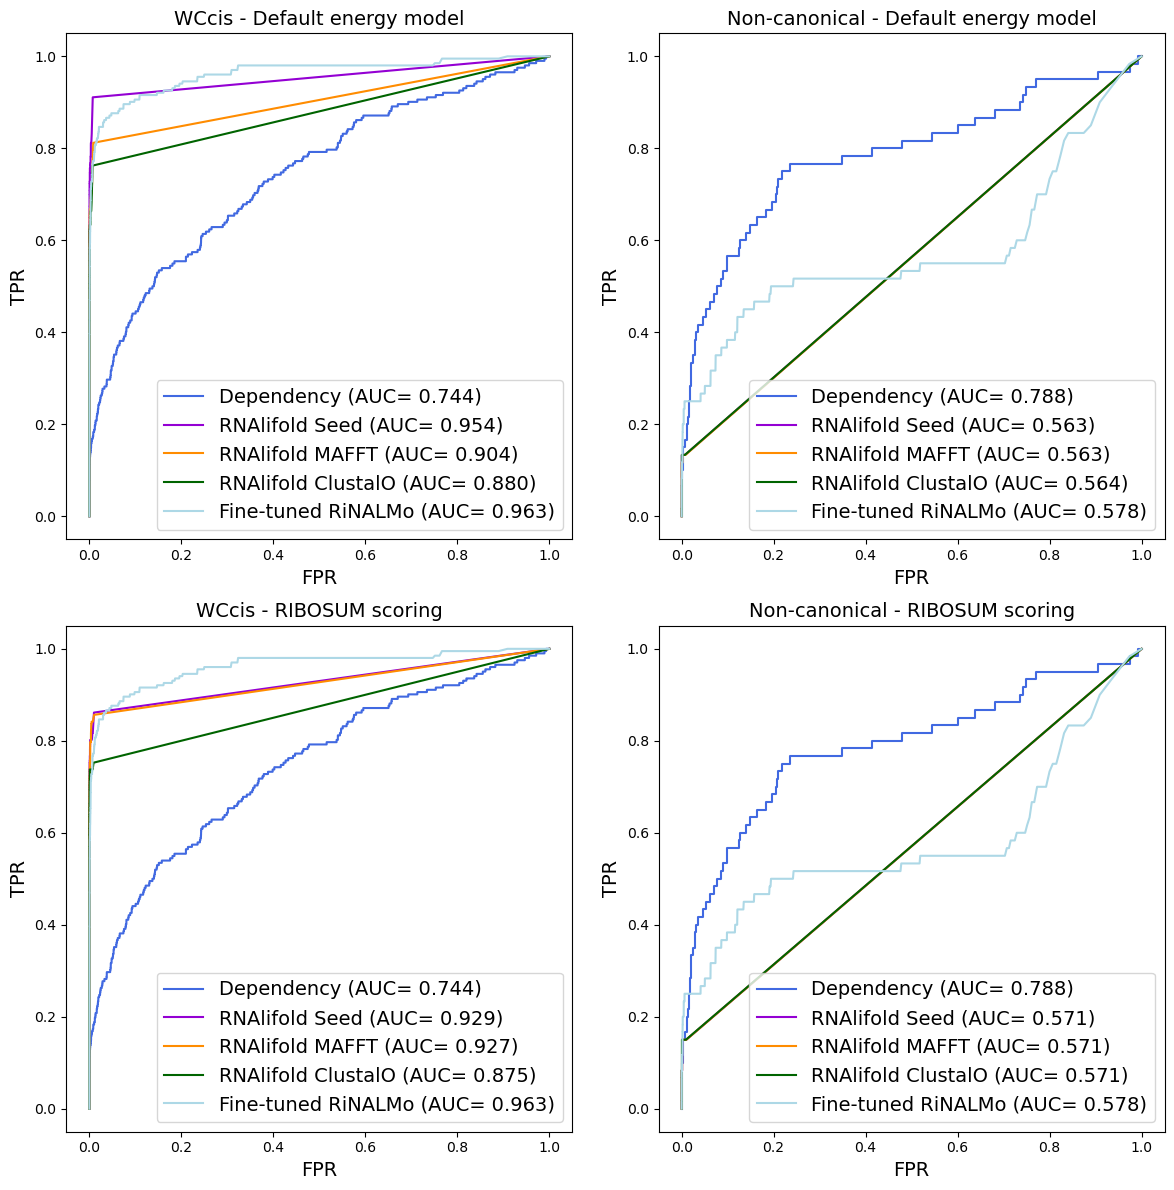

In [23]:
list_of_result_dicts = [dict_results_default_wc, dict_results_default_ext, dict_results_ribosum_wc, dict_results_ribosum_ext]
plot_roc_curves_wc_noncanon_pipe1(list_of_result_dicts)

# Case 2

In [25]:
methods = ["ground_truth","rinalmo","seed","mafft","clustalo", "finetuned"]

dict_results_default_wc_case2 = {k:[] for k in methods}
dict_results_default_ext_case2 = {k:[] for k in methods}

dict_results_ribosum_wc_case2 = {k:[] for k in methods}
dict_results_ribosum_ext_case2 = {k:[] for k in methods}
 
for pdb_chain in all_case2_pdbs:

    for alifold_mode in ["default","ribosum"]:

        rfam_id = mapping_unique_comparna_rfam[pdb_chain]
        
        print("\n\n\n")
        print("Processing RFAM id: ", rfam_id)
        print("Processing PDB id:", pdb_chain)
        
        # Get original sequence and ground truth structure from CompaRNA
        file_bpseq_all = os.path.join(data_path, f"CompaRNA_PDB/{pdb_chain}.bpseq")
        orig_seq, bpseq = open_bpseq(file_bpseq_all)  

        # ---------------------Get ground truth---------------------
        allmatrix, WCmatrix, extmatrix = get_comparna_gt(pdb_chain)

        # ---------------------Get RiNALMo results---------------------
        file_rinalmo_mat = os.path.join(rinalmo_dir, f"rinalmo_{pdb_chain}.npy")
        ci_matrix = np.load(file_rinalmo_mat)

        # ---------------------Get Fine-tuned Rinalmo results---------------------
        probpath = os.path.join(os.path.join(data_path, 'comparna_pdb_WCcis/probs/',pdb_chain+"_probs.npy"))
        finetuned_preds = np.load(probpath)
        
        # ---------------------Get RNAalifold SEED results---------------------
        file_alifold_seed = os.path.join(dict_output_dirs["seed"], f"rnaalifold_{pdb_chain}_{rfam_id}_{alifold_mode}_ALIOUT.out")
        fasta_alignment = os.path.join(dict_folders_aln["seed"], f"{rfam_id}.fa")
        alifold_seed_mat, clean_seq_seed = get_rnaalifold_reduced_matrix(file_alifold_seed, fasta_alignment, orig_seq)
        print("alifold_seed_mat", alifold_seed_mat.shape)
        # Get the start and end of the alignment wrt to the original sequence
        match = list(re.finditer(clean_seq_seed, orig_seq))[0]
        start, end = match.start(0), match.end(0)
        
        # ---------------------Subsetting based on the seed alignments----------------
        # Because there are cases where the region covered by the alignment is only part of the original CompaRNA PDB sequence
        # Subset the dependency map, gt mat, and  based on the subset obtained from rfam alignment
        ci_matrix = ci_matrix[start:end, start:end]
        finetuned_preds = finetuned_preds[start:end, start:end]
        allmatrix = allmatrix[start:end, start:end]
        WCmatrix = WCmatrix[start:end, start:end]
        extmatrix = extmatrix[start:end, start:end]
        print("ci_matrix", ci_matrix.shape)
        assert ci_matrix.shape  == alifold_seed_mat.shape == WCmatrix.shape == extmatrix.shape == finetuned_preds.shape
        
        # ---------------------More postprocessing----------------
        # Get the coordinates of all GT contacts (WC + ext)
        x_ext, y_ext = np.where(allmatrix == -1)
        x_wc, y_wc = np.where(allmatrix == 1)
        # Get GT noncontact values
        noncontact_mask = np.tri(allmatrix.shape[0],k=-1, dtype=bool).T
        # Remove WCcis and ext contacts from the noncontact mask
        noncontact_mask[x_ext, y_ext] = False
        noncontact_mask[x_wc, y_wc] = False
        gt_noncontact = allmatrix[noncontact_mask]
        # Get GT contact values
        len_targ_wc = int(len(x_wc) / 2)
        len_targ_ext = int(len(x_ext) / 2)
        x_wc, y_wc = x_wc[:len_targ_wc], y_wc[:len_targ_wc]
        x_ext, y_ext = x_ext[:len_targ_ext], y_ext[:len_targ_ext]
        gt_contact_wc = WCmatrix[x_wc, y_wc]
        gt_contact_ext = extmatrix[x_ext, y_ext]

        if alifold_mode == "default":
            # ---------------------Record info for Dependency maps and RNAalifold on seed alignment---------------------
            dict_results_default_wc_case2["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_wc)))
            dict_results_default_ext_case2["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_ext)))
            
            dict_results_default_wc_case2["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_wc, y_wc))
            dict_results_default_ext_case2["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_ext, y_ext))

            dict_results_default_wc_case2["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_wc, y_wc))
            dict_results_default_ext_case2["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_ext, y_ext))
            
            dict_results_default_wc_case2["seed"].append(get_predicted_matrix(alifold_seed_mat, noncontact_mask, x_wc, y_wc))
            dict_results_default_ext_case2["seed"].append(get_predicted_matrix(alifold_seed_mat, noncontact_mask, x_ext, y_ext))
            
            # ---------------------Process results when other aligners are used---------------------
            for method in ["mafft","clustalo"]:
            
                file_final_aliout = os.path.join(dict_output_dirs[method], f"rnaalifold_{pdb_chain}_{rfam_id}_{alifold_mode}_ALIOUT.out")
                assert(os.path.exists(file_final_aliout))
                fasta_alignment = os.path.join(dict_folders_aln[method], f"{pdb_chain}_{rfam_id}_aligned.fa")
                pred_mat, clean_seq = get_rnaalifold_reduced_matrix_fasta(file_final_aliout, fasta_alignment, orig_seq, method=method) 
                # pred_mat = pred_mat[start:end, start:end]
                print("pred_mat", pred_mat.shape)
                print("WCmatrix", WCmatrix.shape)
                assert ci_matrix.shape  == alifold_seed_mat.shape == WCmatrix.shape == extmatrix.shape == pred_mat.shape
            
                # ---------------------Record info---------------------
                dict_results_default_wc_case2[method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_wc, y_wc))
                dict_results_default_ext_case2[method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_ext, y_ext))

        elif alifold_mode == "ribosum":
            
            # ---------------------Record info for Dependency maps and RNAalifold on seed alignment---------------------
            dict_results_ribosum_wc_case2["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_wc)))
            dict_results_ribosum_ext_case2["ground_truth"].append(np.concatenate((gt_noncontact, gt_contact_ext)))
            
            dict_results_ribosum_wc_case2["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_wc, y_wc))
            dict_results_ribosum_ext_case2["rinalmo"].append(get_predicted_matrix(ci_matrix, noncontact_mask, x_ext, y_ext))

            dict_results_ribosum_wc_case2["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_wc, y_wc))
            dict_results_ribosum_ext_case2["finetuned"].append(get_predicted_matrix(finetuned_preds, noncontact_mask, x_ext, y_ext))
            
            dict_results_ribosum_wc_case2["seed"].append(get_predicted_matrix(alifold_seed_mat, noncontact_mask, x_wc, y_wc))
            dict_results_ribosum_ext_case2["seed"].append(get_predicted_matrix(alifold_seed_mat, noncontact_mask, x_ext, y_ext))
            
            # ---------------------Process results when other aligners are used---------------------
            for method in ["mafft","clustalo"]: 
            
                file_final_aliout = os.path.join(dict_output_dirs[method], f"rnaalifold_{pdb_chain}_{rfam_id}_{alifold_mode}_ALIOUT.out")
                assert(os.path.exists(file_final_aliout))
                fasta_alignment = os.path.join(dict_folders_aln[method], f"{pdb_chain}_{rfam_id}_aligned.fa")
                pred_mat, clean_seq = get_rnaalifold_reduced_matrix_fasta(file_final_aliout, fasta_alignment, orig_seq, method=method)
                # pred_mat = pred_mat[start:end, start:nd]
                print("pred_mat.shape", pred_mat.shape)
                assert ci_matrix.shape  == alifold_seed_mat.shape == WCmatrix.shape == extmatrix.shape == pred_mat.shape
                
                # ---------------------Record info---------------------
                dict_results_ribosum_wc_case2[method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_wc, y_wc))
                dict_results_ribosum_ext_case2[method].append(get_predicted_matrix(pred_mat, noncontact_mask, x_ext, y_ext))





Processing RFAM id:  RF00207
Processing PDB id: 2KE6_A
alifold_seed_mat (44, 44)
ci_matrix (44, 44)
pred_mat (44, 44)
WCmatrix (44, 44)
pred_mat (44, 44)
WCmatrix (44, 44)




Processing RFAM id:  RF00207
Processing PDB id: 2KE6_A
alifold_seed_mat (44, 44)
ci_matrix (44, 44)
pred_mat.shape (44, 44)
pred_mat.shape (44, 44)




Processing RFAM id:  RF00207
Processing PDB id: 2KUR_A
alifold_seed_mat (48, 48)
ci_matrix (48, 48)
pred_mat (48, 48)
WCmatrix (48, 48)
pred_mat (48, 48)
WCmatrix (48, 48)




Processing RFAM id:  RF00207
Processing PDB id: 2KUR_A
alifold_seed_mat (48, 48)
ci_matrix (48, 48)
pred_mat.shape (48, 48)
pred_mat.shape (48, 48)




Processing RFAM id:  RF00207
Processing PDB id: 2KUU_A
alifold_seed_mat (48, 48)
ci_matrix (48, 48)
pred_mat (48, 48)
WCmatrix (48, 48)
pred_mat (48, 48)
WCmatrix (48, 48)




Processing RFAM id:  RF00207
Processing PDB id: 2KUU_A
alifold_seed_mat (48, 48)
ci_matrix (48, 48)
pred_mat.shape (48, 48)
pred_mat.shape (48, 48)




Processing R

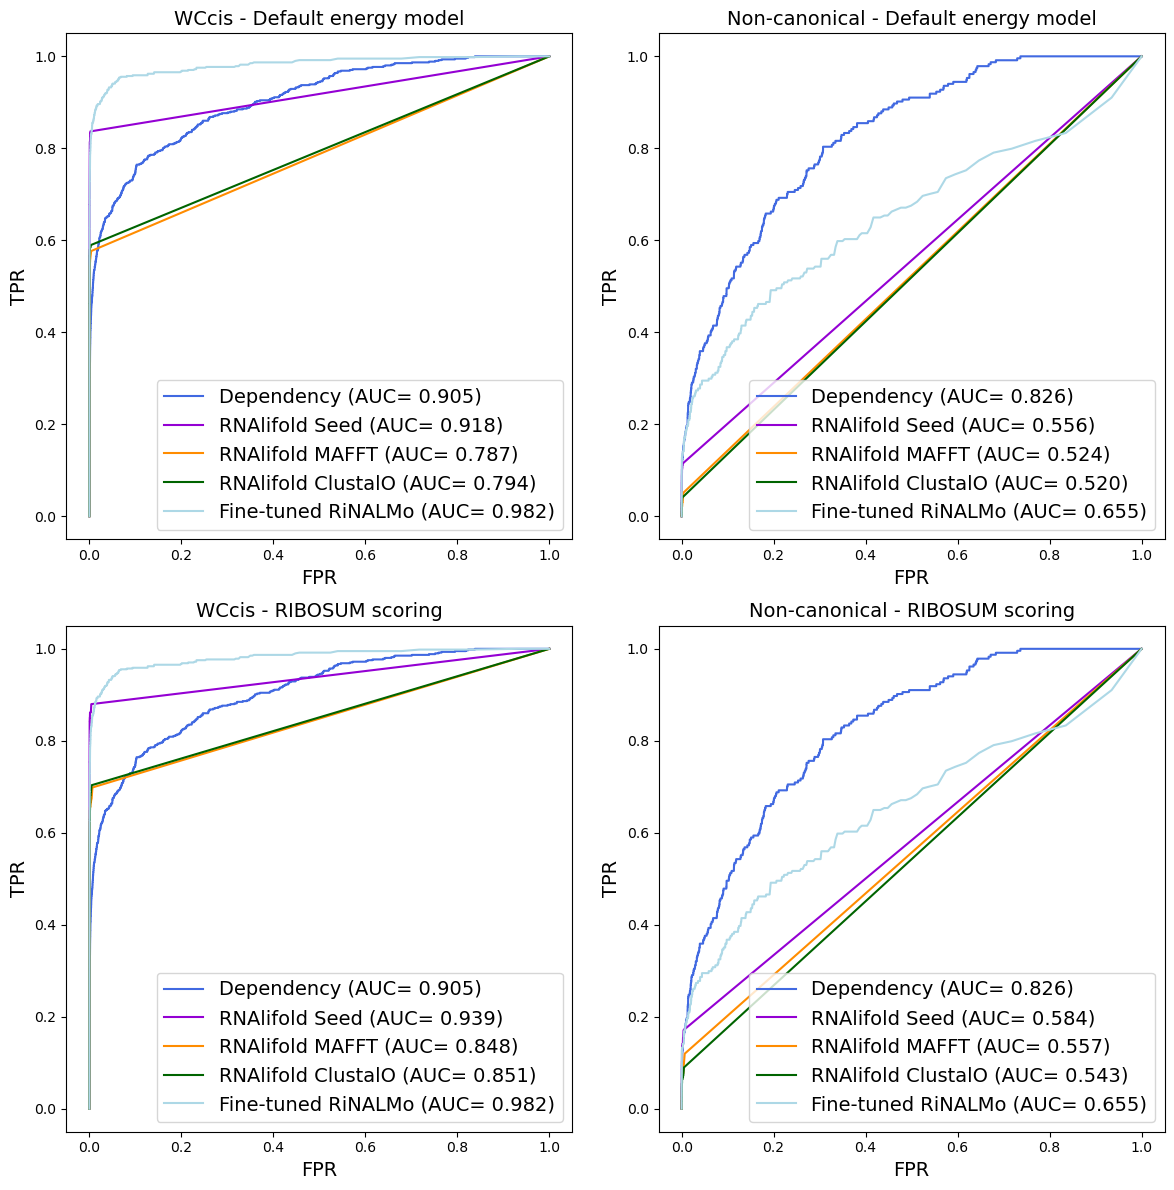

In [26]:
# Plot the ROC curves
list_result_dicts_case2 = [dict_results_default_wc_case2, dict_results_default_ext_case2, dict_results_ribosum_wc_case2, dict_results_ribosum_ext_case2]
plot_roc_curves_wc_noncanon_pipe1(list_result_dicts_case2)

# Combine results

In [27]:
def merge_dicts(d1, d2):
    
    ds = [d1, d2]
    d = {}
    for k in d1.keys():
        d[k] = d1[k] + d2[k]
    return d

In [28]:
# Sanity check
len(set(all_case1_pdbs).intersection(set(all_case2_pdbs)))

0

In [29]:
dict_default_wc = merge_dicts(dict_results_default_wc, dict_results_default_wc_case2)
dict_default_ext = merge_dicts(dict_results_default_ext, dict_results_default_ext_case2)
dict_ribosum_wc = merge_dicts(dict_results_ribosum_wc, dict_results_ribosum_wc_case2)
dict_ribosum_ext = merge_dicts(dict_results_ribosum_ext, dict_results_ribosum_ext_case2)

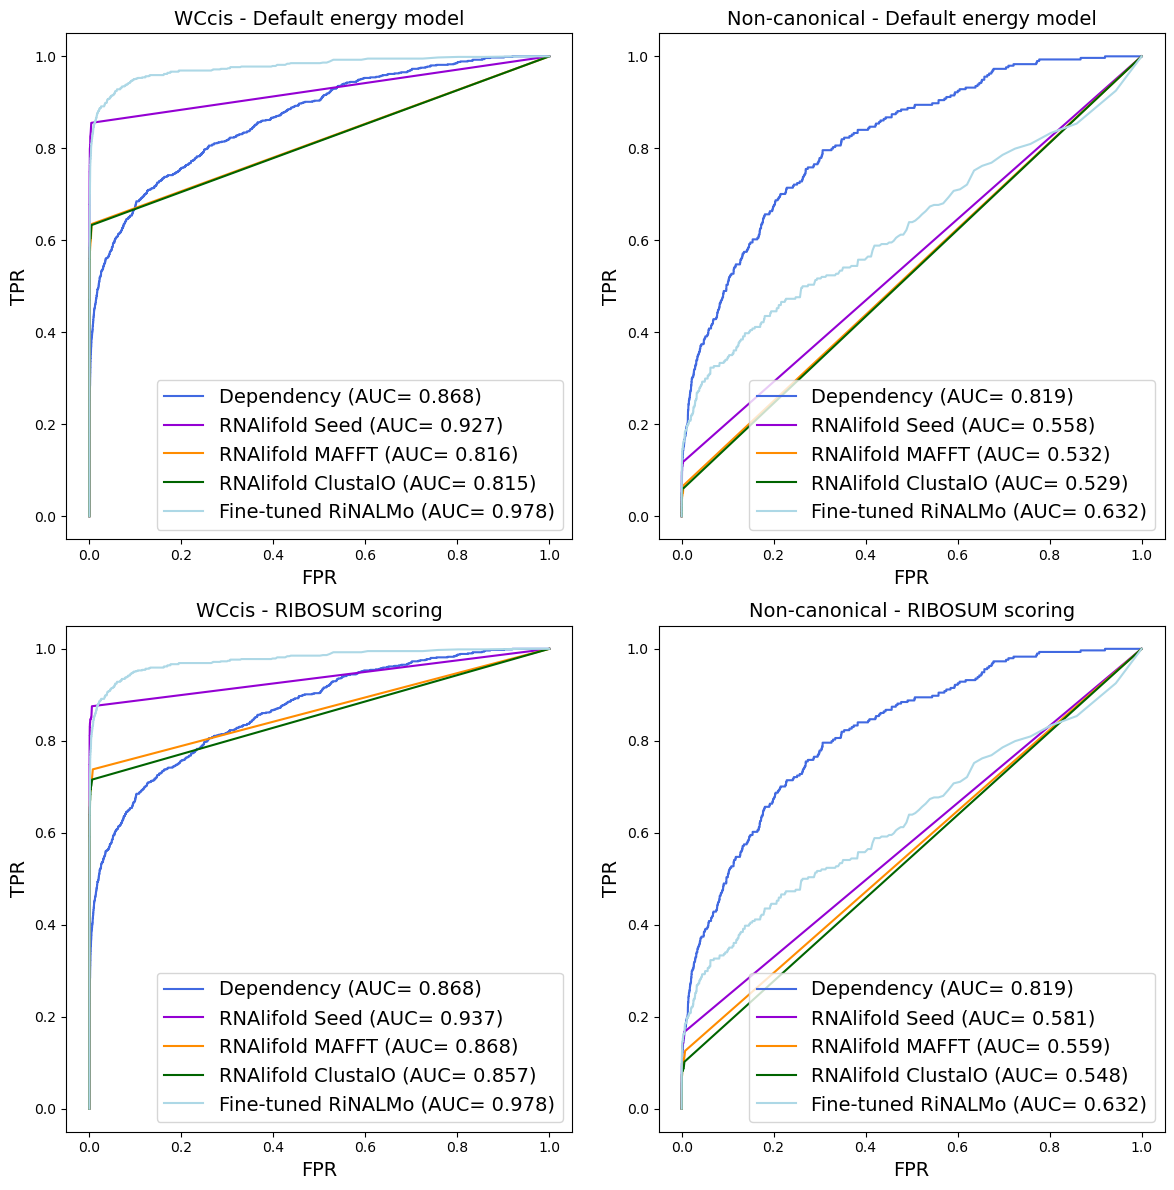

In [30]:
# Plot ROC curves
list_of_result_dicts = [dict_default_wc, dict_default_ext, dict_ribosum_wc, dict_ribosum_ext]
plot_roc_curves_wc_noncanon_pipe1(list_of_result_dicts)